# Movie Data Loading and Cleaning

This notebook contains the data loading and cleaning process for the Movie AI Recommender system.

## Sections:
1. Data Loading and Initial Exploration
2. Data Cleaning and Preprocessing
3. Feature Engineering
4. Model Training and Evaluation
5. Saving Processed Data and Models

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import json
import ast
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error


Merge MOvies + Credits Into One DaataaSets

In [37]:
credits = pd.read_csv("../data/tmdb_5000_credits.csv")
movies = pd.read_csv("../data/tmdb_5000_movies.csv")

In [38]:
credits.rename(columns = {'movie_id': 'id'},inplace = True)

#Merge
data = movies.merge(credits,on = 'id')

data.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [39]:
data['genres']

0       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1       [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3       [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
                              ...                        
4798    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4799    [{"id": 35, "name": "Comedy"}, {"id": 10749, "...
4800    [{"id": 35, "name": "Comedy"}, {"id": 18, "nam...
4801                                                   []
4802                  [{"id": 99, "name": "Documentary"}]
Name: genres, Length: 4803, dtype: object

Clean Json File  

Columns like genre,keywords ,cast ,crew are stored as JSON string

In [40]:
import ast 

def clean_json_column(col):
    return col.apply(lambda x : [i['name'] for i in ast.literal_eval(x)])


data['genres'] = clean_json_column(data['genres'])
data['keywords'] = clean_json_column(data['keywords'])
data['cast'] = clean_json_column(data['cast'])
data['crew'] = clean_json_column(data['crew'])


In [41]:
data['overview'] = data['overview'].fillna('')

data['overview'] = data['overview'].astype(str)

In [42]:
data['genres']

0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4798                        [Action, Crime, Thriller]
4799                                [Comedy, Romance]
4800               [Comedy, Drama, Romance, TV Movie]
4801                                               []
4802                                    [Documentary]
Name: genres, Length: 4803, dtype: object

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8')


Genre Distribution Plot

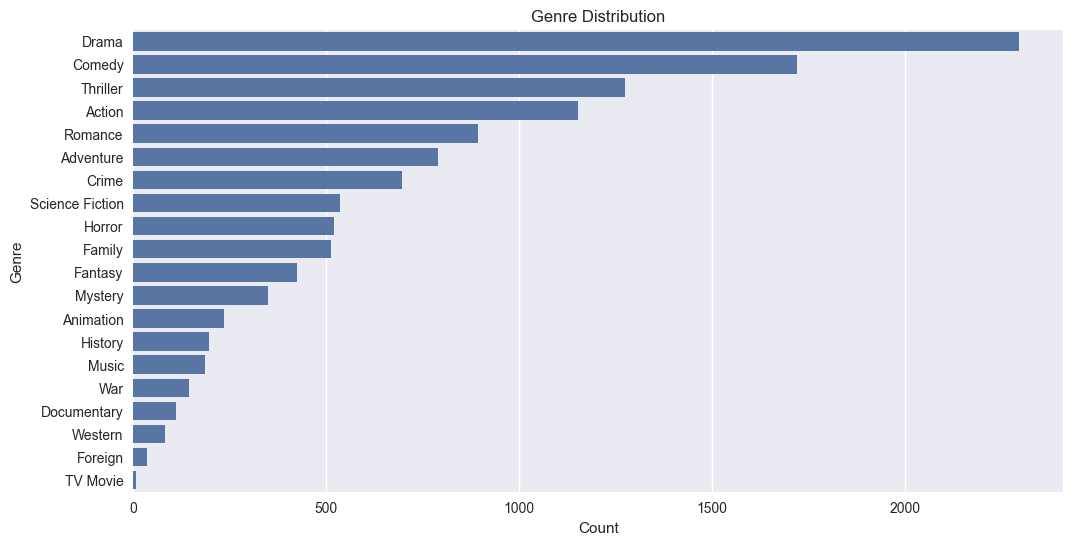

In [44]:
# Flatten list of genres
all_genres = [genre for sublist in data['genres'] for genre in sublist]

plt.figure(figsize=(12,6))
sns.countplot(y=all_genres, order=pd.Series(all_genres).value_counts().index)
plt.title("Genre Distribution")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


Budget Vs Revenue Scatter Plot

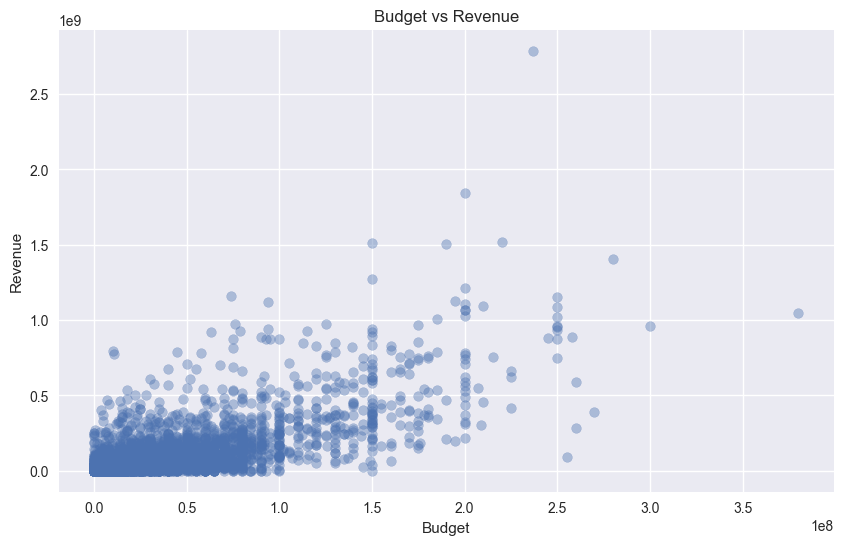

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(data['budget'], data['revenue'], alpha=0.4)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


Top Actores By Frequency

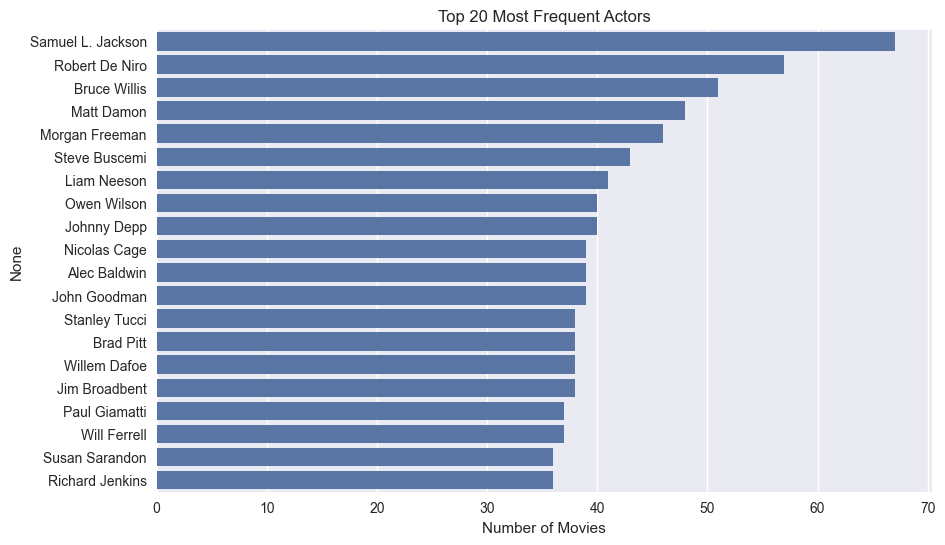

In [46]:
all_cast = [actor for sublist in data['cast'] for actor in sublist]
top_actors = pd.Series(all_cast).value_counts().head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title("Top 20 Most Frequent Actors")
plt.xlabel("Number of Movies")
plt.show()


Movie Runtime Distribution

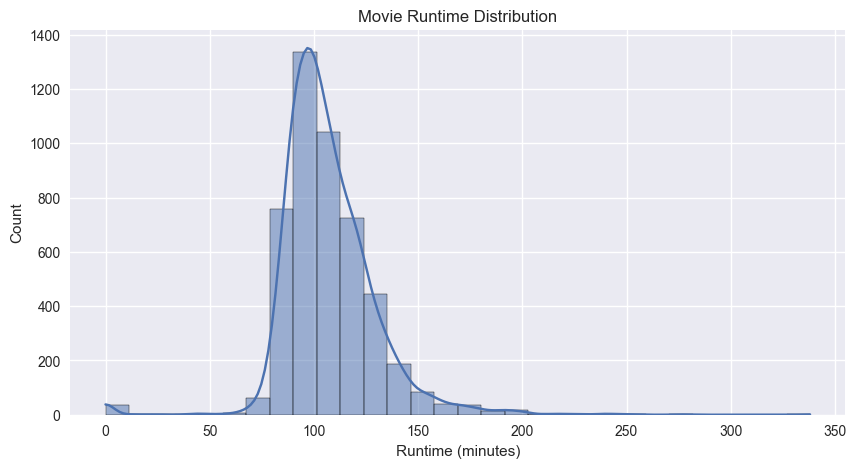

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(data['runtime'], bins=30, kde=True)
plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (minutes)")
plt.show()


Create a “tags” column

We need a single text column combining:

genres

keywords

cast

overview

In [48]:
data["cast"]

0       [Sam Worthington, Zoe Saldana, Sigourney Weave...
1       [Johnny Depp, Orlando Bloom, Keira Knightley, ...
2       [Daniel Craig, Christoph Waltz, Léa Seydoux, R...
3       [Christian Bale, Michael Caine, Gary Oldman, A...
4       [Taylor Kitsch, Lynn Collins, Samantha Morton,...
                              ...                        
4798    [Carlos Gallardo, Jaime de Hoyos, Peter Marqua...
4799    [Edward Burns, Kerry Bishé, Marsha Dietlein, C...
4800    [Eric Mabius, Kristin Booth, Crystal Lowe, Geo...
4801    [Daniel Henney, Eliza Coupe, Bill Paxton, Alan...
4802    [Drew Barrymore, Brian Herzlinger, Corey Feldm...
Name: cast, Length: 4803, dtype: object

In [49]:
def collapse_list(l):
    return " ".join(l).replace(" ","")

data['genres_collapsed'] = data['genres'].apply(collapse_list)
data['keywords_collapsed'] = data['keywords'].apply(collapse_list)
data['cast_collapsed'] = data['cast'].apply(lambda x: " ".join(x[:5]).replace(" ", ""))  # top 5 actors
data['overview_cleaned'] = data['overview'].apply(lambda x: x.lower())



data['tags'] = (
    data['genres_collapsed'] + " " +
    data['keywords_collapsed'] + " " +
    data['cast_collapsed'] + " " +
    data['overview_cleaned']
)




In [50]:
data['tags'][1]

"AdventureFantasyAction oceandrugabuseexoticislandeastindiatradingcompanyloveofone'slifetraitorshipwreckstrongwomanshipalliancecalypsoafterlifefighterpirateswashbuckleraftercreditsstinger JohnnyDeppOrlandoBloomKeiraKnightleyStellanSkarsgårdChowYun-fat captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems."

In [51]:
# Rename title_x to title
data.rename(columns={'title_x': 'title'}, inplace=True)

# Drop title_y because it's duplicate
if 'title_y' in data.columns:
    data.drop(columns=['title_y'], inplace=True)


In [52]:
data[['title','tags']].head()

,title,tags
0,Avatar,ActionAdventureFantasyScienceFiction culturecl...
1,Pirates of the Caribbean: At World's End,AdventureFantasyAction oceandrugabuseexoticisl...
2,Spectre,ActionAdventureCrime spybasedonnovelsecretagen...
3,The Dark Knight Rises,ActionCrimeDramaThriller dccomicscrimefightert...
4,John Carter,ActionAdventureScienceFiction basedonnovelmars...


Use TF-IDF Vectorizer

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

vectors = tfidf.fit_transform(data['tags']).toarray()
vectors.shape


(4803, 5000)

Compute Cosine Similarity Matrix 

This matrix allows us to find similar movies instantly

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)


Buils the Recommendation Function

In [55]:
def recommend(movie):
    movie = movie.lower()
    if movie not in data['title'].str.lower().values:
        return ['Movie not found in database']


    index = data[data['title'].str.lower() == movie].index[0]
    distances = similarity[index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:11]
    
    return [data.iloc[i[0]].title for i in movies_list]

you should get 10 similar movies

In [56]:
recommend('Avatar')

['Apollo 18',
 'The American',
 'Beowulf',
 'Tears of the Sun',
 'The Adventures of Pluto Nash',
 'The Book of Life',
 'Hanna',
 'Semi-Pro',
 'Blood and Chocolate',
 'Transformers: Age of Extinction']

In [57]:
import pickle

# Save vectorizer
pickle.dump(tfidf, open('../models/tfidf_vectorizer.pkl', 'wb'))

# Save similarity matrix
pickle.dump(similarity, open('../models/cosine_similarity.pkl', 'wb'))

# Save cleaned data
data.to_pickle('../models/cleaned_movie_data.pkl')


MoOD BASED MOVIE RECOMMENDATION

Define Mood

In [58]:
mood_genre_map = {
    "happy": ["Comedy", "Family"],
    "sad": ["Drama", "Romance"],
    "thrilling": ["Action", "Thriller", "Crime"],
    "romantic": ["Romance"],
    "scary": ["Horror"],
    "calm": ["Animation", "Fantasy"]
}


In [59]:
def recommend_by_mood(mood, top_n=10):
    mood = mood.lower()
    
    if mood not in mood_genre_map:
        return ["Mood not supported"]
    
    genres = mood_genre_map[mood]
    
    filtered = data[data['genres'].apply(lambda x: any(g in x for g in genres))]
    
    return filtered['title'].head(top_n).tolist()


In [60]:
recommend_by_mood("happy")


['Tangled',
 'Harry Potter and the Half-Blood Prince',
 'The Chronicles of Narnia: Prince Caspian',
 'Men in Black 3',
 'Alice in Wonderland',
 'Monsters University',
 'Oz: The Great and Powerful',
 'Cars 2',
 'Toy Story 3',
 'Jack the Giant Slayer']

In [61]:
recommend_by_mood("thrilling")



['Avatar',
 "Pirates of the Caribbean: At World's End",
 'Spectre',
 'The Dark Knight Rises',
 'John Carter',
 'Spider-Man 3',
 'Avengers: Age of Ultron',
 'Batman v Superman: Dawn of Justice',
 'Superman Returns',
 'Quantum of Solace']

In [62]:
recommend_by_mood("sad")

['The Dark Knight Rises',
 'King Kong',
 'Titanic',
 'World War Z',
 'The Great Gatsby',
 'Prince of Persia: The Sands of Time',
 'A Christmas Carol',
 'The Dark Knight',
 'Hugo',
 'Inside Out']

Hit / Flop Prediction (Classification Model)

profit_ratio = revenue / budget

Hit   → profit_ratio >= 2
Flop  → profit_ratio < 2
?

Create  Target Columns

In [63]:
# Avoid division errors
data = data[(data['budget'] > 0) & (data['revenue'] > 0)]

data['profit_ratio'] = data['revenue'] / data['budget']

data['hit_flop'] = data['profit_ratio'].apply(lambda x: 1 if x >= 2 else 0)

data[['title', 'budget', 'revenue', 'profit_ratio', 'hit_flop']].head()


,title,budget,revenue,profit_ratio,hit_flop
0,Avatar,237000000,2787965087,11.763566,1
1,Pirates of the Caribbean: At World's End,300000000,961000000,3.203333,1
2,Spectre,245000000,880674609,3.594590,1
3,The Dark Knight Rises,250000000,1084939099,4.339756,1
4,John Carter,260000000,284139100,1.092843,0


Select Features

In [64]:
features = data[['budget', 'popularity', 'vote_average']]
target = data['hit_flop']


In [65]:
features = features.fillna(features.median())


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

importances = clf.feature_importances_
feature_names = features.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance for Hit/Flop Prediction")
plt.show()


NameError: name 'clf' is not defined

In [ ]:
data['genres']

0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4773                                         [Comedy]
4788                          [Horror, Comedy, Crime]
4792               [Crime, Horror, Mystery, Thriller]
4796               [Science Fiction, Drama, Thriller]
4798                        [Action, Crime, Thriller]
Name: genres, Length: 3229, dtype: object

In [ ]:
print(type(data['genres']))

df = pd.DataFrame(data['genres'])


df

<class 'pandas.core.series.Series'>


,genres
0,"[Action, Adventure, Fantasy, Science Fiction]"
1,"[Adventure, Fantasy, Action]"
2,"[Action, Adventure, Crime]"
3,"[Action, Crime, Drama, Thriller]"
4,"[Action, Adventure, Science Fiction]"
...,...
4773,[Comedy]
4788,"[Horror, Comedy, Crime]"
4792,"[Crime, Horror, Mystery, Thriller]"
4796,"[Science Fiction, Drama, Thriller]"


In [ ]:
df['genres'].dropna()

0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4773                                         [Comedy]
4788                          [Horror, Comedy, Crime]
4792               [Crime, Horror, Mystery, Thriller]
4796               [Science Fiction, Drama, Thriller]
4798                        [Action, Crime, Thriller]
Name: genres, Length: 3229, dtype: object

In [ ]:
a = [1,2,3]
b = (1,2,3)
c = {1}

print(type(c))

c.add(4)

<class 'set'>


In [ ]:
a = {"Thriller"}
for i in df['genres'].value_counts().index:
    for c in i:
        a.add(c)

In [ ]:
print(a)

{'War', 'Crime', 'History', 'Thriller', 'Fantasy', 'Mystery', 'Horror', 'Family', 'Comedy', 'Science Fiction', 'Western', 'Foreign', 'Documentary', 'Animation', 'Music', 'Adventure', 'Romance', 'Action', 'Drama'}


In [ ]:
votecount = data.sort_values(by = "vote_count",ascending = False)

In [ ]:
title = votecount["original_title"].head(10).values

In [ ]:
count = votecount['vote_count'].head(10)

In [ ]:
count

96     13752
65     12002
0      11800
16     11776
788    10995
95     10867
287    10099
94      9742
426     9455
127     9427
Name: vote_count, dtype: int64

In [ ]:
title

array(['Inception', 'The Dark Knight', 'Avatar', 'The Avengers',
       'Deadpool', 'Interstellar', 'Django Unchained',
       'Guardians of the Galaxy', 'The Hunger Games',
       'Mad Max: Fury Road'], dtype=object)

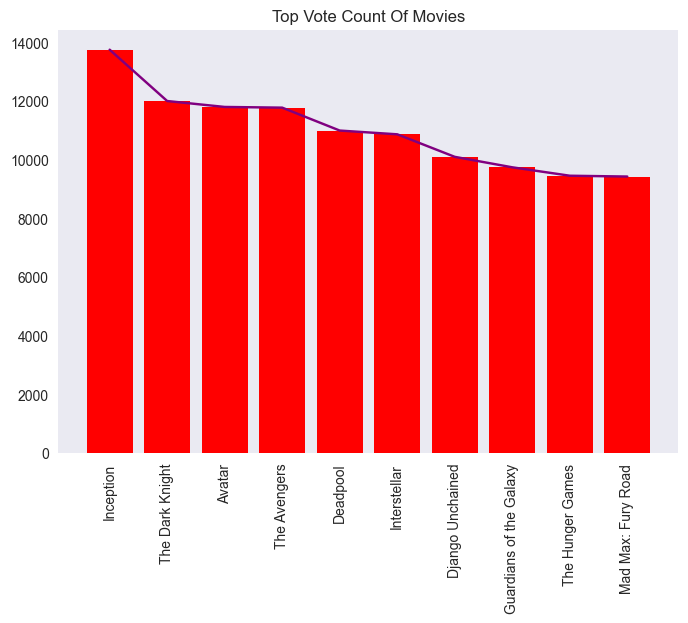

In [ ]:
plt.bar(title,count,color = 'r')
plt.xticks(rotation = 90)
plt.plot(title,count,color = "purple")
plt.grid()
plt.title("Top Vote Count Of Movies")
plt.show()

In [ ]:
title = votecount["original_title"].tail(10).values
count = votecount['vote_count'].tail(10)



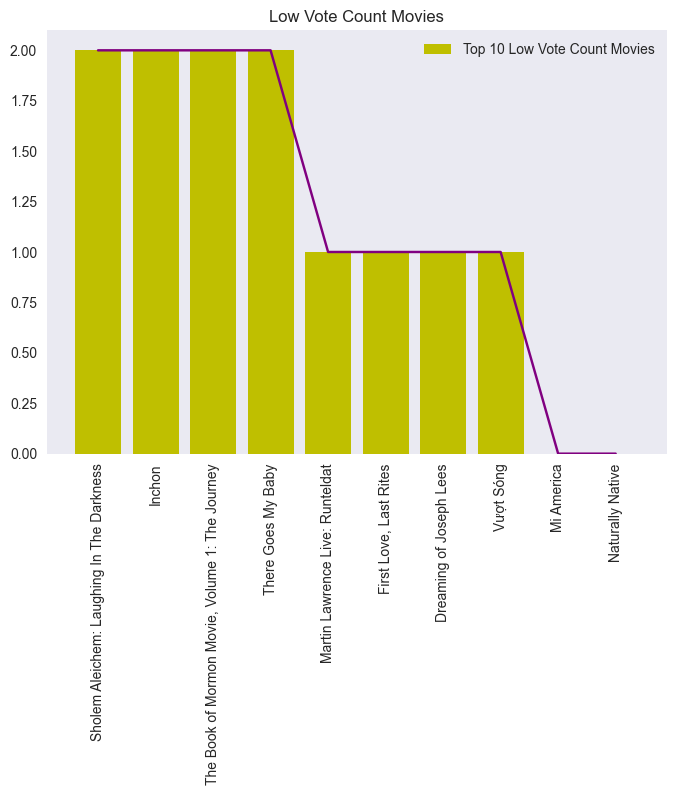

In [ ]:
plt.bar(title,count,color = "y",label = "Top 10 Low Vote Count Movies")
plt.plot(title,count,color = 'purple')
plt.title("Low Vote Count Movies")
plt.legend()
plt.xticks(rotation = 90)
plt.grid()
plt.show()

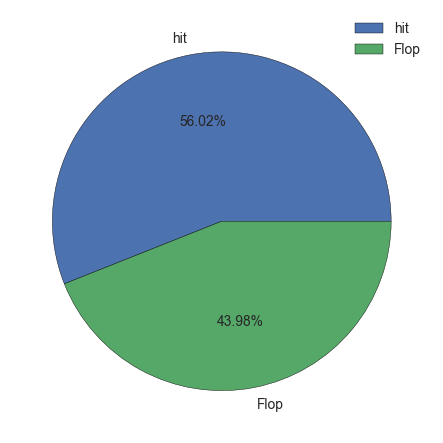

In [ ]:
hit_flop = data["hit_flop"].value_counts()
plt.pie(hit_flop.values,labels = ["hit","Flop"],autopct = "%1.2f%%",wedgeprops = {"edgecolor" : "black"})
plt.legend()
plt.show()

In [ ]:
data

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_count,cast,crew,genres_collapsed,keywords_collapsed,cast_collapsed,overview_cleaned,tags,profit_ratio,hit_flop
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",ActionAdventureFantasyScienceFiction,cultureclashfuturespacewarspacecolonysocietysp...,SamWorthingtonZoeSaldanaSigourneyWeaver,"in the 22nd century, a paraplegic marine is di...",ActionAdventureFantasyScienceFiction culturecl...,11.763566,1
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",AdventureFantasyAction,oceandrugabuseexoticislandeastindiatradingcomp...,JohnnyDeppOrlandoBloomKeiraKnightley,"captain barbossa, long believed to be dead, ha...",AdventureFantasyAction oceandrugabuseexoticisl...,3.203333,1
2,245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",ActionAdventureCrime,spybasedonnovelsecretagentsequelmi6britishsecr...,DanielCraigChristophWaltzLéaSeydoux,a cryptic message from bond’s past sends him o...,ActionAdventureCrime spybasedonnovelsecretagen...,3.594590,1
3,250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,9106,"[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",ActionCrimeDramaThriller,dccomicscrimefighterterroristsecretidentitybur...,ChristianBaleMichaelCaineGaryOldman,following the death of district attorney harve...,ActionCrimeDramaThriller dccomicscrimefightert...,4.339756,1
4,260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",ActionAdventureScienceFiction,basedonnovelmarsmedallionspacetravelprincessal...,TaylorKitschLynnCollinsSamanthaMorton,"john carter is a war-weary, former military ca...",ActionAdventureScienceFiction basedonnovelmars...,1.092843,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4773,27000,[Comedy],http://www.miramax.com/movie/clerks/,2292,"[salesclerk, loser, aftercreditsstinger]",en,Clerks,Convenience and video store clerks Dante and R...,19.748658,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...",...,755,"[Brian O'Halloran, Jeff Anderson, Jason Mewes,...","[Kevin Smith, Kevin Smith, Kevin Smith, Kevin ...",Comedy,salesclerkloseraftercreditsstinger,BrianO'HalloranJeffAndersonJasonMewes,convenience and video store clerks dante and r...,Comedy salesclerkloseraftercreditsstinger Bria...,116.708519,1
4788,12000,"[Horror

In [ ]:
data['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [ ]:
data["cast"]

0       [Sam Worthington, Zoe Saldana, Sigourney Weave...
1       [Johnny Depp, Orlando Bloom, Keira Knightley, ...
2       [Daniel Craig, Christoph Waltz, Léa Seydoux, R...
3       [Christian Bale, Michael Caine, Gary Oldman, A...
4       [Taylor Kitsch, Lynn Collins, Samantha Morton,...
                              ...                        
4773    [Brian O'Halloran, Jeff Anderson, Jason Mewes,...
4788    [Divine, David Lochary, Mary Vivian Pearce, Mi...
4792    [Koji Yakusho, Masato Hagiwara, Tsuyoshi Ujiki...
4796    [Shane Carruth, David Sullivan, Casey Gooden, ...
4798    [Carlos Gallardo, Jaime de Hoyos, Peter Marqua...
Name: cast, Length: 3229, dtype: object

In [ ]:
data["crew"]

0       [Stephen E. Rivkin, Rick Carter, Christopher B...
1       [Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...
2       [Thomas Newman, Sam Mendes, Anna Pinnock, John...
3       [Hans Zimmer, Charles Roven, Christopher Nolan...
4       [Andrew Stanton, Andrew Stanton, John Lasseter...
                              ...                        
4773    [Kevin Smith, Kevin Smith, Kevin Smith, Kevin ...
4788    [John Waters, John Waters, John Waters, John W...
4792                 [Kiyoshi Kurosawa, Kiyoshi Kurosawa]
4796    [Shane Carruth, Shane Carruth, Shane Carruth, ...
4798    [Robert Rodriguez, Robert Rodriguez, Robert Ro...
Name: crew, Length: 3229, dtype: object

In [ ]:
member = credits["crew"][0]


In [ ]:
credits["cast"]

0       [{"cast_id": 242, "character": "Jake Sully", "...
1       [{"cast_id": 4, "character": "Captain Jack Spa...
2       [{"cast_id": 1, "character": "James Bond", "cr...
3       [{"cast_id": 2, "character": "Bruce Wayne / Ba...
4       [{"cast_id": 5, "character": "John Carter", "c...
                              ...                        
4798    [{"cast_id": 1, "character": "El Mariachi", "c...
4799    [{"cast_id": 1, "character": "Buzzy", "credit_...
4800    [{"cast_id": 8, "character": "Oliver O\u2019To...
4801    [{"cast_id": 3, "character": "Sam", "credit_id...
4802    [{"cast_id": 3, "character": "Herself", "credi...
Name: cast, Length: 4803, dtype: object

In [ ]:
datanew = data
datanew['cast_collapsed'] = data['cast'].apply(lambda x: " ".join(x[:3]).replace(" ", ""))  # top 3 actors


In [ ]:
data["cast_collapsed"].head()

0    SamWorthingtonZoeSaldanaSigourneyWeaver
1       JohnnyDeppOrlandoBloomKeiraKnightley
2        DanielCraigChristophWaltzLéaSeydoux
3        ChristianBaleMichaelCaineGaryOldman
4      TaylorKitschLynnCollinsSamanthaMorton
Name: cast_collapsed, dtype: object